In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

   Feature_1  Feature_2
0  -7.155244  -7.390016
1  -7.395875  -7.110843
2  -2.015671   8.281780
3   4.509270   2.632436
4  -8.102502  -7.484961


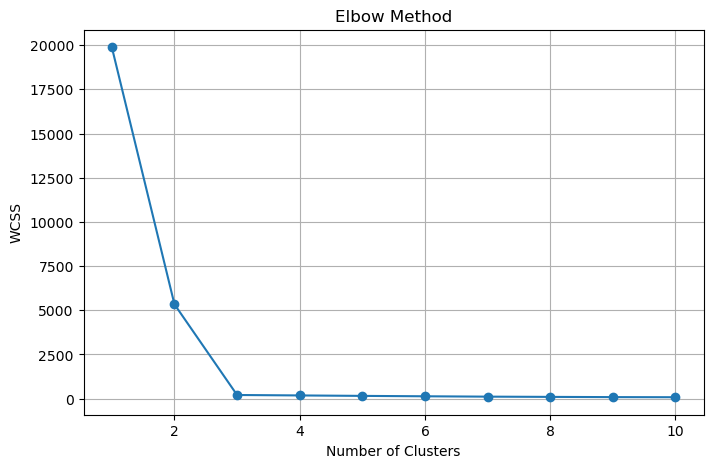

   Feature_1  Feature_2  Cluster
0  -7.155244  -7.390016        1
1  -7.395875  -7.110843        1
2  -2.015671   8.281780        0
3   4.509270   2.632436        2
4  -8.102502  -7.484961        1


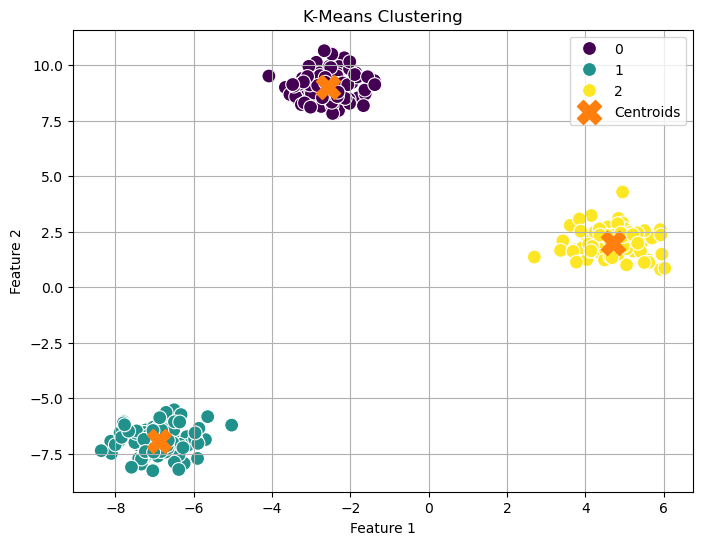

Silhouette Score: 0.908


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

print(df.head())

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        max_iter=300,
        n_init=10,
        random_state=42
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid()
plt.show()

kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

print(df.head())

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="Feature_1",
    y="Feature_2",
    hue="Cluster",
    data=df,
    palette="viridis",
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()
plt.show()

score = silhouette_score(X, clusters)

print("Silhouette Score:", round(score, 3))